In [ ]:
#Overview of Student's performance in Math subject
import pandas as pd
import zipfile
with zipfile.ZipFile('/content/archive.zip', 'r') as zip_ref:
    zip_ref.extractall('/content')
df = pd.read_csv('student_math_clean.csv')
df.head()

,student_id,school,sex,age,address_type,family_size,parent_status,mother_education,father_education,mother_job,...,family_relationship,free_time,social,weekday_alcohol,weekend_alcohol,health,absences,grade_1,grade_2,final_grade
0,1,GP,F,18,Urban,Greater than 3,Apart,higher education,higher education,at_home,...,4,3,4,1,1,3,6,5,6,6
1,2,GP,F,17,Urban,Greater than 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,5,3,3,1,1,3,4,5,5,6
2,3,GP,F,15,Urban,Less than or equal to 3,Living together,primary education (4th grade),primary education (4th grade),at_home,...,4,3,2,2,3,3,10,7,8,10
3,4,GP,F,15,Urban,Greater than 3,Living together,higher education,5th to 9th grade,health,...,3,2,2,1,1,5,2,15,14,15
4,5,GP,F,16,Urban,Greater than 3,Living together,secondary education,secondary education,other,...,4,3,2,1,2,5,4,6,10,10


**Encoding**

In [ ]:
#Binary: Misc
df["school"] = df["school"].replace({"MS": 1, "GP": 0})
df["sex"] = df["sex"].replace({"F": 1, "M": 0})
df["address_type"] = df["address_type"].replace({"Urban": 1, "Rural": 0})
df["family_size"] = df["family_size"].replace({"Greater than 3": 1, "Less than or equal to 3": 0})
df["parent_status"] = df["parent_status"].replace({"Living together": 1, "Apart": 0})

#Binary: Yes/No
df["school_support"] = df["school_support"].replace({"yes": 1, "no": 0})
df["family_support"] = df["family_support"].replace({"yes": 1, "no": 0})
df["extra_paid_classes"] = df["extra_paid_classes"].replace({"yes": 1, "no": 0})
df["activities"] = df["activities"].replace({"yes": 1, "no": 0})
df["nursery_school"] = df["nursery_school"].replace({"yes": 1, "no": 0})
df["higher_ed"] = df["higher_ed"].replace({"yes": 1, "no": 0})
df["internet_access"] = df["internet_access"].replace({"yes": 1, "no": 0})
df["romantic_relationship"] = df["romantic_relationship"].replace({"yes": 1, "no": 0})

In [ ]:
#Ordinal
travel = {'<15 min.': 0, '15 to 30 min.': 1, '30 min. to 1 hour': 2, '>1 hour':3}
df["travel_time"] = df["travel_time"].map(travel)

study = {'<2 hours': 0, '2 to 5 hours': 1, '5 to 10 hours': 2, '>10 hours':3}
df["study_time"] = df["study_time"].map(study)

In [ ]:
#One-hot
categorical_cols = ["mother_education", "mother_job", "father_education", "father_job", "school_choice_reason", "guardian"]
encoded_df = pd.get_dummies(df, columns=categorical_cols, prefix=categorical_cols, prefix_sep='_')

In [ ]:
df["school_choice_reason"].value_counts()

,count
school_choice_reason,
course,145
home,109
reputation,105
other,36


In [ ]:
encoded_df

,student_id,school,sex,age,address_type,family_size,parent_status,travel_time,study_time,class_failures,...,father_job_other,father_job_services,father_job_teacher,school_choice_reason_course,school_choice_reason_home,school_choice_reason_other,school_choice_reason_reputation,guardian_father,guardian_mother,guardian_other
0,1,0,1,18,1,1,0,1,1,0,...,False,False,True,True,False,False,False,False,True,False
1,2,0,1,17,1,1,1,0,1,0,...,True,False,False,True,False,False,False,True,False,False
2,3,0,1,15,1,0,1,0,1,3,...,True,False,False,False,False,True,False,False,True,False
3,4,0,1,15,1,1,1,0,2,0,...,False,True,False,False,True,False,False,False,True,False
4,5,0,1,16,1,1,1,0,1,0,...,True,False,False,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390,391,1,0,20,1,0,0,0,1,2,...,False,True,False,True,False,False,False,False,False,True
391,392,1,0,17,1,0,1,1,0,0,...,False,True,False,True,False,False,False,False,True,False
392,393,1,0,21,0,1,1,0,0,3,...,True,False,False,True,False,False,False,False,False,True
393,394,1,0,18,0,0,1,2,0,0,...,True,False,False,True,False,False,False,False,True,False


In [ ]:
encoded_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 55 columns):
 #   Column                                          Non-Null Count  Dtype
---  ------                                          --------------  -----
 0   student_id                                      395 non-null    int64
 1   school                                          395 non-null    int64
 2   sex                                             395 non-null    int64
 3   age                                             395 non-null    int64
 4   address_type                                    395 non-null    int64
 5   family_size                                     395 non-null    int64
 6   parent_status                                   395 non-null    int64
 7   travel_time                                     395 non-null    int64
 8   study_time                                      395 non-null    int64
 9   class_failures                                  395 non-null    i

**Get X and y**

In [ ]:
y = encoded_df["final_grade"]
X = encoded_df.drop(["final_grade", "student_id", "school"], axis=1)

In [ ]:
y

,final_grade
0,6
1,6
2,10
3,15
4,10
...,...
390,9
391,16
392,7
393,10


**Train - test split**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**XGBoost model**

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score

# Create and train the XGBoost model
xgb_model = xgb.XGBRegressor(
    alpha =5,
    colsample_bynode= 0.8,
    eta= 0.1,
    n_estimators= 100,
    subsample= 1)
# xgb_model = xgb.XGBRegressor(
#     colsample_bynode= 0.6,
#     eta= 0.05,
#     reg_lambda= 0.5,
#     n_estimators= 200,
#     subsample = 0.5) # You can adjust hyperparameters
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_y_train_pred = xgb_model.predict(X_train)
xgb_y_test_pred = xgb_model.predict(X_test)

# Evaluate the XGBoost model
xgb_train_mse = mean_squared_error(y_train, xgb_y_train_pred)
xgb_train_r2 = r2_score(y_train, xgb_y_train_pred)
xgb_test_mse = mean_squared_error(y_test, xgb_y_test_pred)
xgb_test_r2 = r2_score(y_test, xgb_y_test_pred)

print(f"XGBoost Training MSE: {xgb_train_mse:.2f}")
print(f"XGBoost Training RMSE: {(xgb_train_mse)**0.5:.2f}")
print(f"XGBoost Training R-squared: {xgb_train_r2:.2f}")
print(f"XGBoost Testing MSE: {xgb_test_mse:.2f}")
print(f"XGBoost Testing RMSE: {(xgb_test_mse)**0.5:.2f}")
print(f"XGBoost Testing R-squared: {xgb_test_r2:.2f}")

XGBoost Training MSE: 0.96
XGBoost Training RMSE: 0.98
XGBoost Training R-squared: 0.95
XGBoost Testing MSE: 14.37
XGBoost Testing RMSE: 3.79
XGBoost Testing R-squared: 0.30


In [ ]:
import shap
explainer = shap.Explainer(xgb_model)
#shap_values = explainer(X_test)

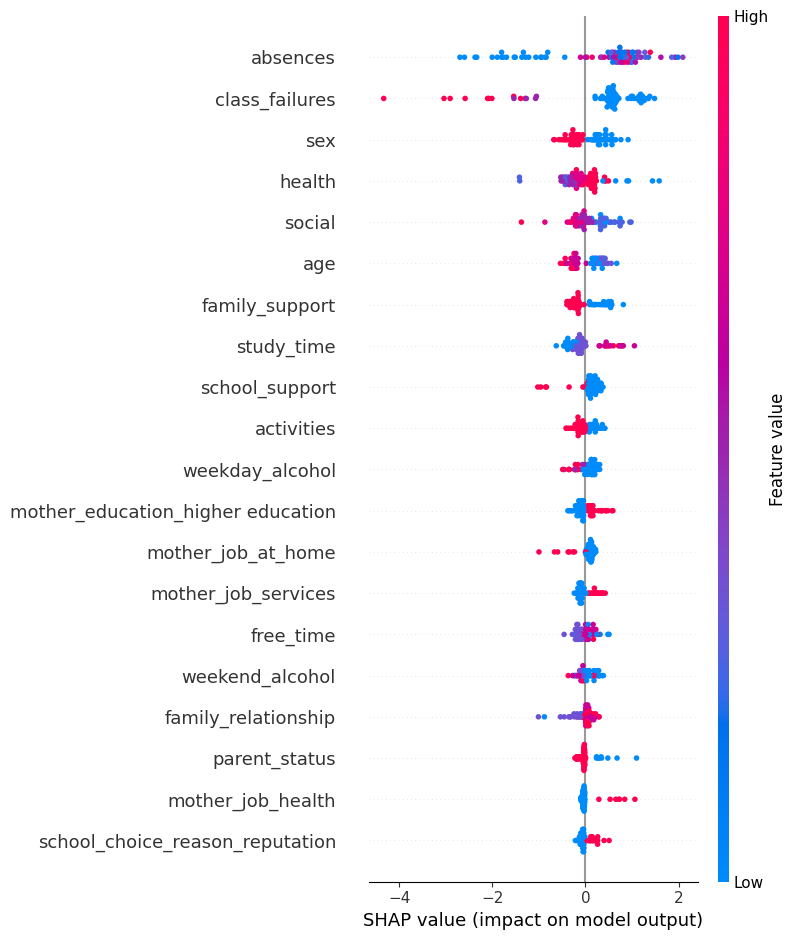

In [ ]:
shap.summary_plot(shap_values, X_test)

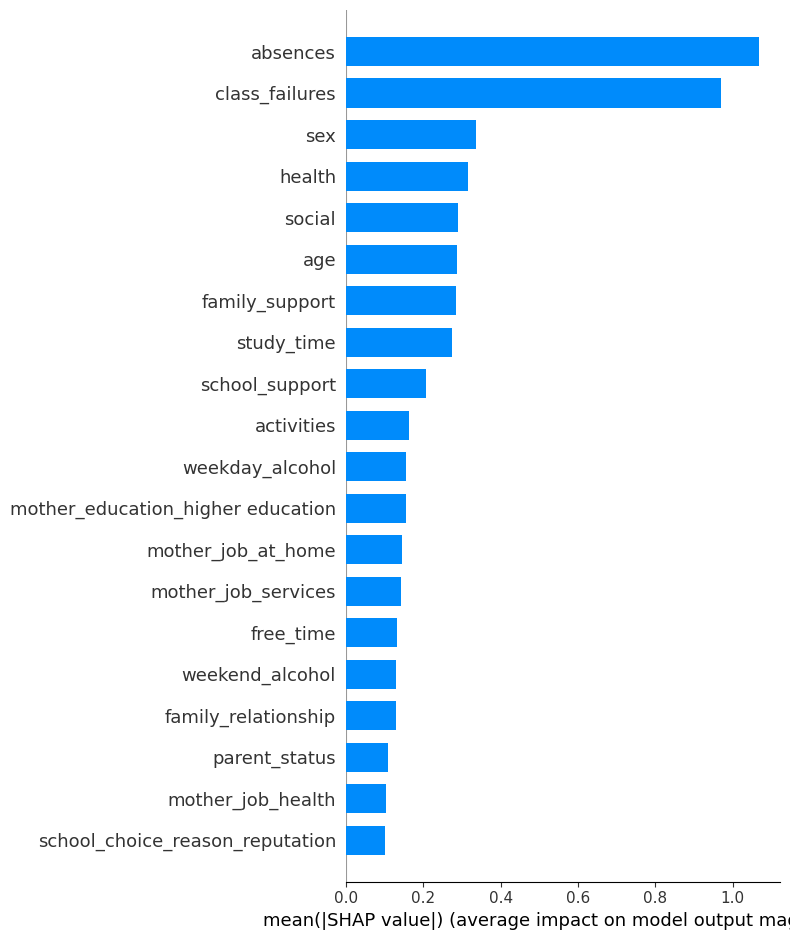

In [ ]:
shap.summary_plot(shap_values, X_test, plot_type="bar")

In [ ]:
explainer = shap.Explainer(xgb_model)
shap_values = explainer(X)
shap.plots.waterfall(shap_values[0])

XGBoostError: [01:48:01] /workspace/src/c_api/c_api_utils.h:127: Check failed: std::accumulate(shape.cbegin(), shape.cend(), static_cast<bst_ulong>(1), std::multiplies<>{}) == chunksize * rows (20935 vs. 20145) : 
Stack trace:
  [bt] (0) /usr/local/lib/python3.10/dist-packages/xgboost/lib/libxgboost.so(+0x22dcbc) [0x7804a8e2dcbc]
  [bt] (1) /usr/local/lib/python3.10/dist-packages/xgboost/lib/libxgboost.so(+0x236a81) [0x7804a8e36a81]
  [bt] (2) /usr/local/lib/python3.10/dist-packages/xgboost/lib/libxgboost.so(XGBoosterPredictFromDMatrix+0x3e5) [0x7804a8d3bd25]
  [bt] (3) /lib/x86_64-linux-gnu/libffi.so.8(+0x7e2e) [0x7805079f0e2e]
  [bt] (4) /lib/x86_64-linux-gnu/libffi.so.8(+0x4493) [0x7805079ed493]
  [bt] (5) /usr/lib/python3.10/lib-dynload/_ctypes.cpython-310-x86_64-linux-gnu.so(+0xa3e9) [0x780507a163e9]
  [bt] (6) /usr/lib/python3.10/lib-dynload/_ctypes.cpython-310-x86_64-linux-gnu.so(+0x9a00) [0x780507a15a00]
  [bt] (7) /usr/bin/python3(_PyObject_MakeTpCall+0x25b) [0x5ba3908dab4b]
 